In [13]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.metrics import r2_score
from scipy.stats import norm, rankdata
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import torch
import torch.nn as nn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [14]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction 
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 9

Function 1 - Week 9
Largest gap: -19.6 to -39.6
Floor set at: -29.6
Strongest detection: 1.346625e+00 at [0.624182 0.616547]
  log reading: 0.1
Log reading range: -29.6 to 0.1

All points (sorted by detection strength):
  [0.624182 0.616547] --> output: 1.347e+00 --> log reading: 0.1
  [0.65011406 0.68152635] --> output: -3.606e-03 --> log reading: -2.4
  [0.694651 0.629916] --> output: -1.607e-03 --> log reading: -2.8
  [0.461537 0.459084] --> output: -1.688e-05 --> log reading: -4.8
  [0.504751 0.602966] --> output: 1.949e-12 --> log reading: -11.7
  [0.73102363 0.73299988] --> output: 7.711e-16 --> log reading: -15.1
  [0.618043 0.460066] --> output: 2.603e-20 --> log reading: -19.6
  [0.31269116 0.07872278] --> output: -2.089e-91 --> log reading: -29.6
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> log reading: -29.6
  [0.84035342 0.26473161] --> output: 3.342e-124 --> log reading: -29.6
  [0.41043714 0.1475543 ] --> output: -2.159e-54 --> log reading: -29.6
  [0.08250725 0.40

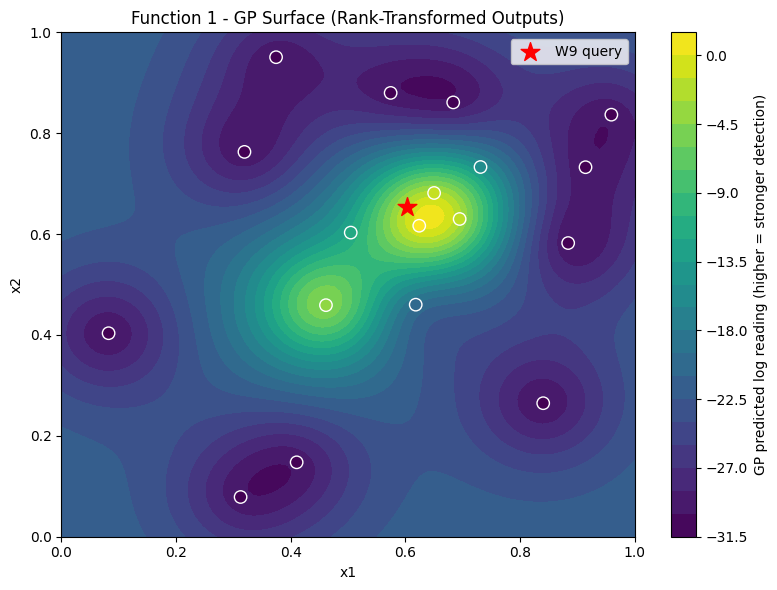

In [15]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes: 
#    - clip ceiling no longer 0.0, to accommodate positive Y values for log reading
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 9")
print("=" * 60)
 
inputs  = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],
    [0.504751, 0.602966],
    [0.624182, 0.616547],
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
    1.9491751435286236e-12,
    1.3466251251333927,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])
 
# log-abs transform: measures detection strength on a log scale
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
ceiling = np.max(np.log10(np.abs(all_outputs) + 1e-300))
log_readings = np.clip(log_readings, floor, ceiling)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")
 
# print all points for verification
print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> log reading: {log_readings[i]:.1f}")


# Instead of the decay metric, use intra-source point separation directly
# use two confirmed source-1 points to generate the ls estimate
source1_points = np.array([[0.65011406, 0.68152635],
                            [0.694651,   0.629916  ]])
intra_source_dist = np.linalg.norm(source1_points[0] - source1_points[1])

# Length scale slightly larger than this so the GP connects them
# but small enough not to merge with the second source at (0.46, 0.46)
ls = intra_source_dist * 1.5 
print(f"\nSuggested length scale: {ls:.3f}")


# GP on log readings
kernel = Matern(nu=2.5, length_scale=0.102, length_scale_bounds="fixed")
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, log_readings)
 
# global candidates with UCB 
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))
 
mu, sigma = gp.predict(candidates, return_std=True)
ucb       = compute_ucb(mu, sigma, kappa=1.5)
 
best_idx = np.argmax(ucb)
query    = candidates[best_idx]
 
print(f"\nWeek 9 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}")
 
# --- Interpretability: 2D heatmap of GP predicted surface ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W9 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2 - week 9 


Function 2 - Week 9
Total points: 18
Current best: 0.685
Feature importances: x1=0.939, x2=0.061

PDP input spans: x1=0.440, x2=0.610
Derived length-scale bounds: x1=(0.0044, 0.440), x2=(0.0061, 0.610)
Learned kernel: Matern(length_scale=[0.0608, 0.61], nu=2.5) + WhiteKernel(noise_level=0.0289)

Week 9 Query: 0.708605-0.579596
  GP mean:   0.667
  GP std:    0.091
  UCB score: 0.804  (kappa=1.5)


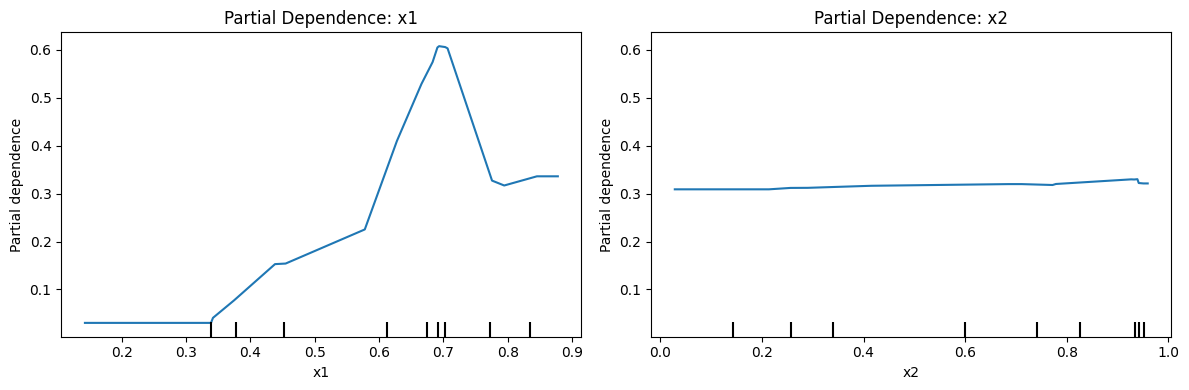

In [16]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# change: 
#    - lowered kappa to 1.5
# =============================================================================

print("\n" + "=" * 60)
print("Function 2 - Week 9")
print("=" * 60)

initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

prev_queries = np.array([
    [0.775510, 0.959184],  # W1: 0.166
    [0.683114, 0.932567],  # W2: 0.570
    [0.794441, 0.256481],  # W3: 0.273
    [0.706387, 0.952221],  # W4: 0.675 
    [0.693183, 0.938929],  # W5: 0.674
    [0.374540, 0.950714],  # W6: 0.096 
    [0.627660, 0.941490],  # W7: 0.311 
    [0.690609, 0.415564],  # W8: 0.684 (best)
])
prev_outputs = np.array([
    0.16576674, 
    0.56974583, 
    0.27313450, 
    0.67545988, 
    0.67430262, 
    0.09612224849190841, 
    0.3113471043593484,
    0.6848335582399823,
])

all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")

# RF fitted for PDP computation only -- not used for acquisition
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")

# --- PDP-derived length-scale bounds ---
# compute PDP for each dimension programmatically
pd_x1 = partial_dependence(rf, all_inputs, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf, all_inputs, features=[1], grid_resolution=100)

# extract input grid and output values
x1_grid   = pd_x1['grid_values'][0]
x1_pd     = pd_x1['average'][0]
x2_grid   = pd_x2['grid_values'][0]
x2_pd     = pd_x2['average'][0]

# find the input span over threshold to identify the active input region  
# considered active in regions where PDP exceeds 20% of its total range
x1_pd_range    = x1_pd.max() - x1_pd.min()
x2_pd_range    = x2_pd.max() - x2_pd.min()

x1_active      = x1_grid[x1_pd >= x1_pd.min() + 0.2 * x1_pd_range]
x2_active      = x2_grid[x2_pd >= x2_pd.min() + 0.2 * x2_pd_range]

x1_input_span  = x1_active.max() - x1_active.min() if len(x1_active) > 1 else 1.0
x2_input_span  = x2_active.max() - x2_active.min() if len(x2_active) > 1 else 1.0

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")

# length-scale upper bound = input span (function varies over this scale)
# length-scale lower bound = small fraction of upper bound
x1_ls_upper = float(np.clip(x1_input_span, 0.1, 1.0))
x2_ls_upper = float(np.clip(x2_input_span, 0.1, 10.0))
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"Derived length-scale bounds: x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

# anisotropic GP with PDP-derived bounds and WhiteKernel
kernel = (Matern(length_scale=[x1_ls_upper / 2, x2_ls_upper / 2],
                 length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                      (x2_ls_lower, x2_ls_upper)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"Learned kernel: {gp.kernel_}")

# UCB using GP posterior variance 
np.random.seed(42)
candidates       = np.random.uniform(0, 1, (50000, 2))
gp_mean, gp_std  = gp.predict(candidates, return_std=True)

kappa            = 1.5
ucb_scores       = gp_mean + kappa * gp_std

best_idx = np.argmax(ucb_scores)
query    = candidates[best_idx]

print(f"\nWeek 9 Query: {format_query(query)}")
print(f"  GP mean:   {gp_mean[best_idx]:.3f}")
print(f"  GP std:    {gp_std[best_idx]:.3f}")
print(f"  UCB score: {ucb_scores[best_idx]:.3f}  (kappa={kappa})")

# --- Interpretability: partial dependence plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf, all_inputs, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

# Function 3 - week 9


Function 3 - Week 9
Total points: 23, best: -0.0000607

RF feature importances:
  A     : 0.0975
  B     : 0.0465
  C     : 0.2395
  A*B   : 0.0587
  A*C   : 0.0565
  B*C   : 0.0519
  A^2   : 0.0372
  B^2   : 0.1308
  C^2   : 0.2813

RF train R²: 0.7281
RF train predictions vs actual:
  predicted: -0.098544, actual: -0.112122
  predicted: -0.089325, actual: -0.087963
  predicted: -0.095931, actual: -0.111415
  predicted: -0.048593, actual: -0.034835
  predicted: -0.070642, actual: -0.048008
  predicted: -0.084463, actual: -0.110621
  predicted: -0.222178, actual: -0.398926
  predicted: -0.151436, actual: -0.113869
  predicted: -0.103027, actual: -0.131461
  predicted: -0.093992, actual: -0.094190
  predicted: -0.067260, actual: -0.046947
  predicted: -0.084073, actual: -0.105965
  predicted: -0.143735, actual: -0.118048
  predicted: -0.072927, actual: -0.036378
  predicted: -0.084804, actual: -0.056758
  predicted: -0.043882, actual: -0.029062
  predicted: -0.064537, actual: -0.062310

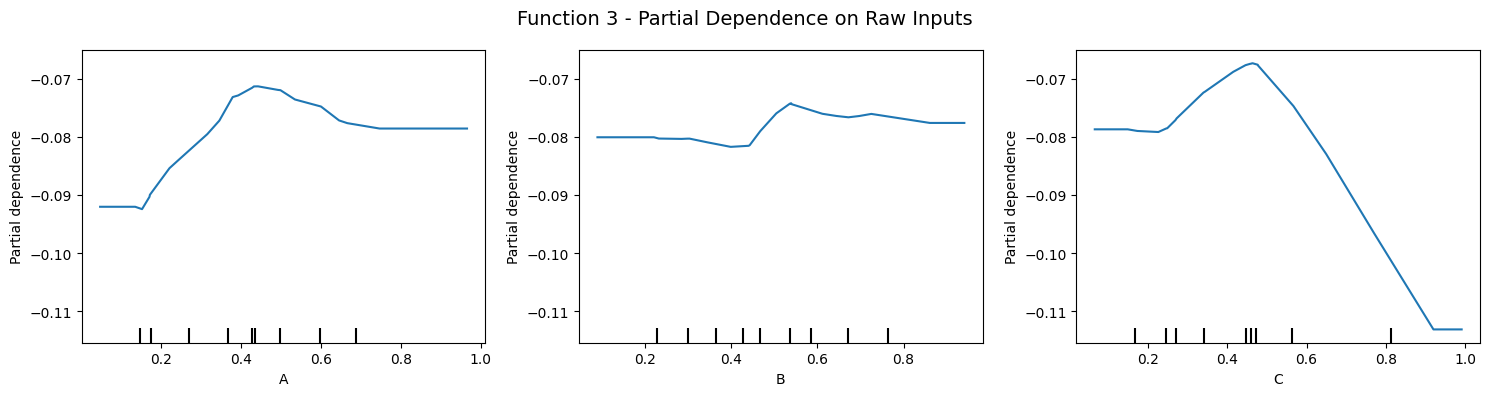

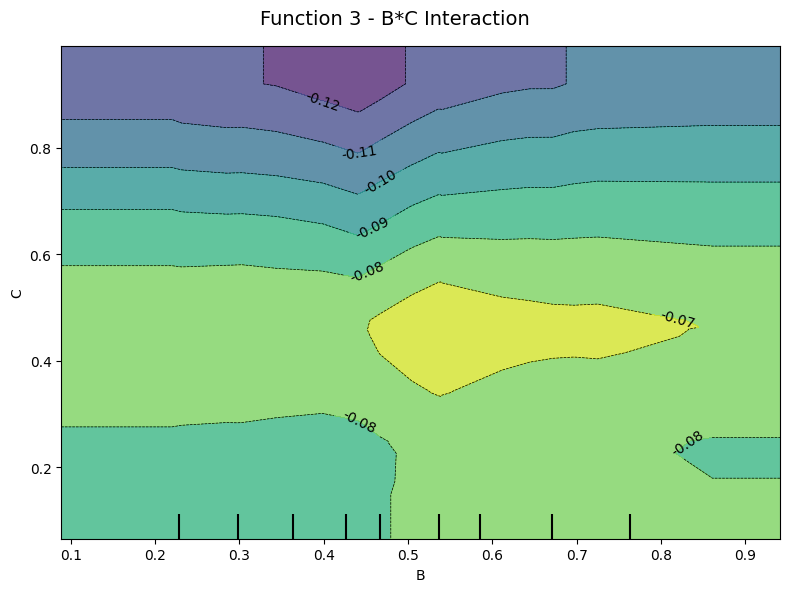

In [17]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D)
# changes:
#   - n_estimators 200 to 500: more stable ensemble mean and std estimates
#   - candidate pool 10,000 to 50,000: better surrogate coverage near peak exclusion filter retained: prevents requerying known points
# =============================================================================

print("\n" + "=" * 60)
print("Function 3 - Week 9")
print("=" * 60)

f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')

prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1: -0.0291
    [0.315339, 0.088659, 0.415174],  # W2: -0.0623
    [0.392735, 0.504381, 0.464332],  # W3: -0.000633
    [0.498607, 0.467046, 0.477827],  # W4: -0.00294
    [0.432840, 0.535542, 0.476983],  # W5: -0.000617
    [0.442511, 0.539648, 0.462840],  # W6: -0.0000607 (best)
    [0.427601, 0.442546, 0.649322],  # W7: -0.0906
    [0.432117, 0.538819, 0.446114],  # W8: -0.00432
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
    -0.09063996317418548,
    -0.004316355713810623,
])

X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])

print(f"Total points: {len(Y)}, best: {Y.max():.7f}")

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

# --- ExtraTrees on polynomial features ---
rf = ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf.fit(X_poly, Y)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

train_preds = rf.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")

# --- Candidate search ---
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 3))

# exclude known points
min_distance = 0.01
distances = np.min(np.linalg.norm(candidates[:, None, :] - X[None, :, :], axis=2), axis=1)
candidates = candidates[distances > min_distance]
cand_poly  = poly.transform(candidates)

rf_preds  = rf.predict(cand_poly)
best_idx  = np.argmax(rf_preds)
query     = candidates[best_idx]

top_n = 10
top_indices = np.argsort(rf_preds)[::-1][:top_n]
print(f"\nTop {top_n} RF candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates[idx])}, RF predicted: {rf_preds[idx]:.6f}")

print(f"\nWeek 9 Query: {format_query(query)}")
print(f"RF predicted: {rf_preds[best_idx]:.6f}")

# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4 - week 9


Function 4 - Week 9
Total points: 38, best: 0.6309

Candidates: 5000 W2 + 3000 W1 + 2000 W4 = 10000 total
LOO R² GP:  0.9236
LOO R² RF:  0.7440

GP fitted kernel: 1.08**2 * Matern(length_scale=[0.809, 0.696, 0.5, 0.724], nu=2.5)

Week 9 Query: 0.425192-0.446783-0.395943-0.413089
mean: -0.396
std:  0.517
UCB:  0.121055


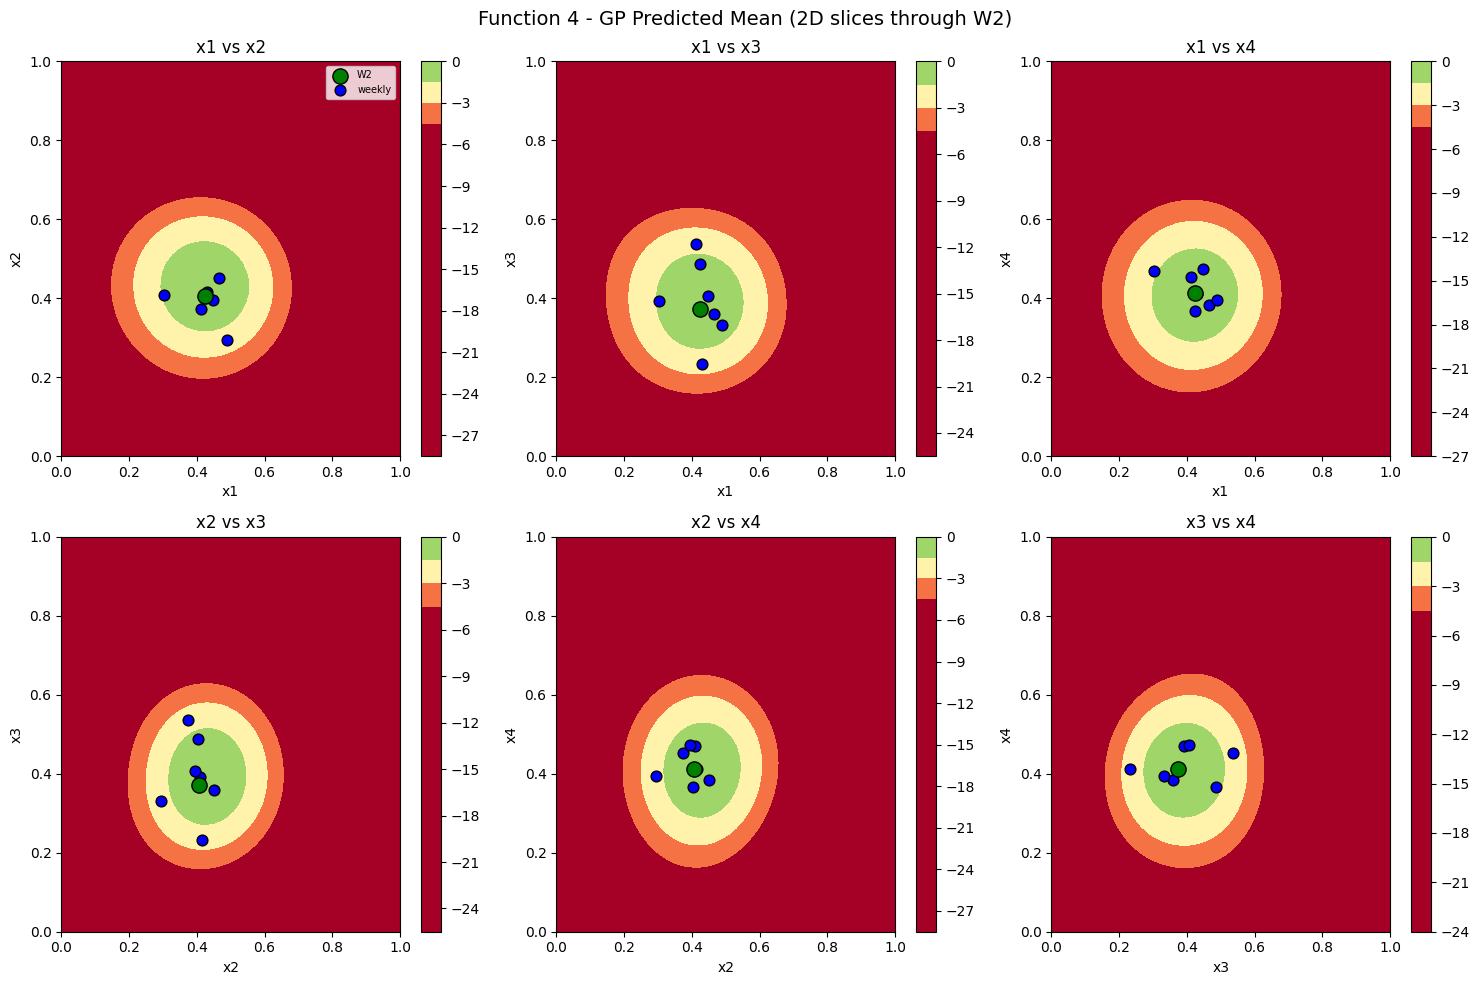

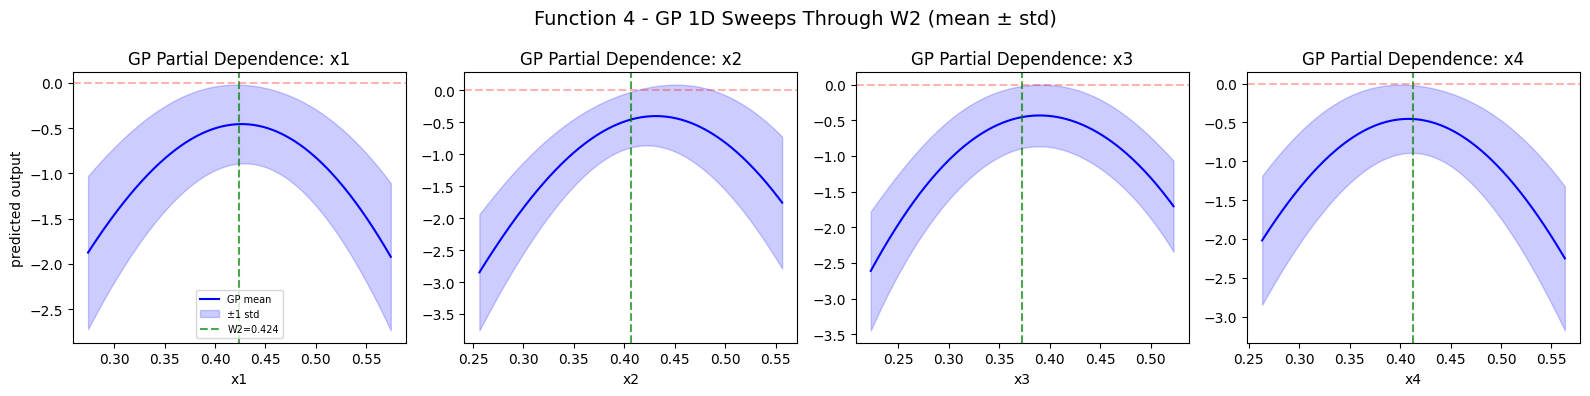

In [18]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   - changed surrogate back to GP + ARD matern (alpha=0.01 to not over-interpolate) 
#   - kept UCB with kappa at 1.0 for isolated change
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 9")
print("=" * 60)
 
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1: -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2: +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3: -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4: -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5: -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6: -2.141
    [0.447976, 0.395249, 0.406174, 0.473345],  # W7: -1.249
    [0.431511, 0.415976, 0.232614, 0.411417],  # W8: -1.993
])
prev_outputs = np.array([
    -0.9654345395220925, 
    0.6308582112564989, 
    -2.1500998298742817,
    -0.9915950770116662, 
    -2.4630197287139697, 
    -2.1414388028868454,
    -1.2497635252595596,
    -1.9932051275194236,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")
 
# Candidate generation -- local search around best three query points
np.random.seed(42)

week1_query = np.array([0.466173, 0.451984, 0.359193, 0.383111])
week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week4_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])

candidates_w2 = np.array([np.clip(week2_query + np.random.normal(0, 0.03, 4), 0, 1) for _ in range(5000)])
candidates_w1 = np.array([np.clip(week1_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(3000)])
candidates_w4 = np.array([np.clip(week4_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(2000)])

candidates = np.vstack([candidates_w2, candidates_w1, candidates_w4])
print(f"\nCandidates: {len(candidates_w2)} W2 + {len(candidates_w1)} W1 + {len(candidates_w4)} W4 = {len(candidates)} total")

# --- GP + ARD Matern surrogate with length scales from W6/W7
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.3, 0.3, 0.2, 0.3],
    length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=0.01, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

# -- LOO R2 comparison with RF
loo = LeaveOneOut()

loo_predictions_gp = np.zeros(len(f4_all_outputs))
for train_idx, test_idx in loo.split(f4_all_inputs):
    kernel_loo = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.3, 0.3, 0.2, 0.3],
        length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
        nu=2.5
    )
    gp_loo = GaussianProcessRegressor(kernel=kernel_loo, n_restarts_optimizer=20, alpha=0.01, normalize_y=True)
    gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
    loo_predictions_gp[test_idx] = gp_loo.predict(f4_all_inputs[test_idx])

loo_predictions_rf = np.zeros(len(f4_all_outputs))
for train_idx, test_idx in loo.split(f4_all_inputs):
    rf_loo = RandomForestRegressor(n_estimators=500, random_state=42)
    rf_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
    loo_predictions_rf[test_idx] = rf_loo.predict(f4_all_inputs[test_idx])

print(f"LOO R2 GP:  {r2_score(f4_all_outputs, loo_predictions_gp):.4f}")
print(f"LOO R2 RF:  {r2_score(f4_all_outputs, loo_predictions_rf):.4f}")

# GP fitted kernel -- length scales show per-dimension sensitivity
print(f"\nGP fitted kernel: {gp.kernel_}")

# GP predictions
mu, sigma = gp.predict(candidates, return_std=True)

# UCB acquisition
kappa = 1.0
ucb = mu + kappa * sigma

best_index = np.argmax(ucb)
query = candidates[best_index]

print(f"\nWeek 9 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"UCB:  {ucb[best_index]:.6f}")
 
# --- Interpretability plots ---
# 2D RF predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week2_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    # plot W2 and other queries
    ax.scatter(week2_query[d1], week2_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(prev_queries[:, d1], prev_queries[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP Predicted Mean (2D slices through W2)', fontsize=14)
plt.tight_layout()
plt.show()

# RF 1D partial dependence through W2 
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week2_query[i] - 0.15, week2_query[i] + 0.15, 200)    
    test_points = np.tile(week2_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W2 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5 - week 9


Function 5 - Week 9
Total points: 28, best so far: 6014.32

Week 9 Query:       0.982974-0.999999-0.999999-0.999999
GP predicted yield: 6516.73
GP std (log scale): 0.3662
SVR prediction:     6549.54
EI:                 0.183890

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2192.5
W2         2381.5     2381.5     2363.5
W3         2689.2     2689.2     2671.7
W4         3223.2     3223.2     3241.0
W5         3287.0     3287.0     3269.4
W6         4354.1     4354.1     4336.1
W7         5255.7     5255.7     5273.7
W8         6014.3     6014.3     5996.4

--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     4432.9     4315.7
  0.50     4597.1     4523.1
  0.55     4713.4     4668.7
  0.60     4872.2     4859.8
  0.65     5089.0     5100.9
  0.70     5368.7     5386.1
  0.75     5694.5     5697.2
  0.80     6024.4     6005.9

--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     4132.3   

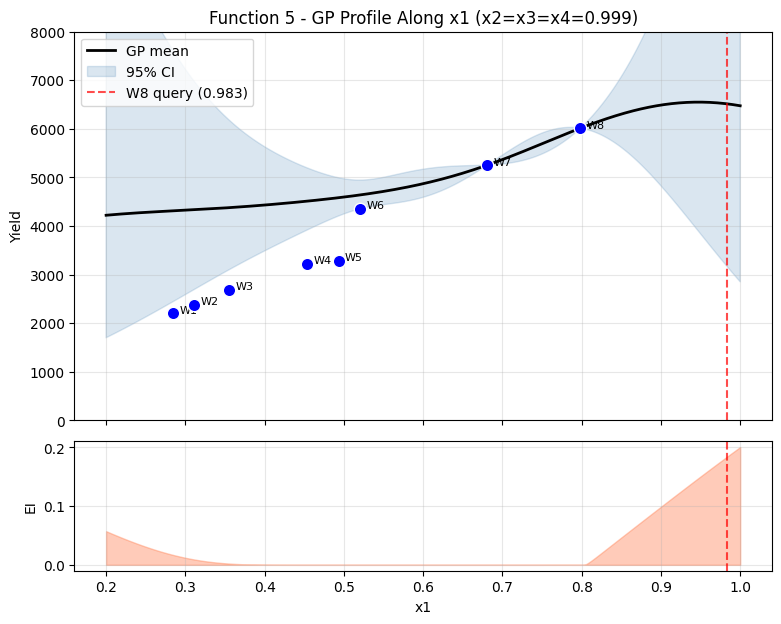

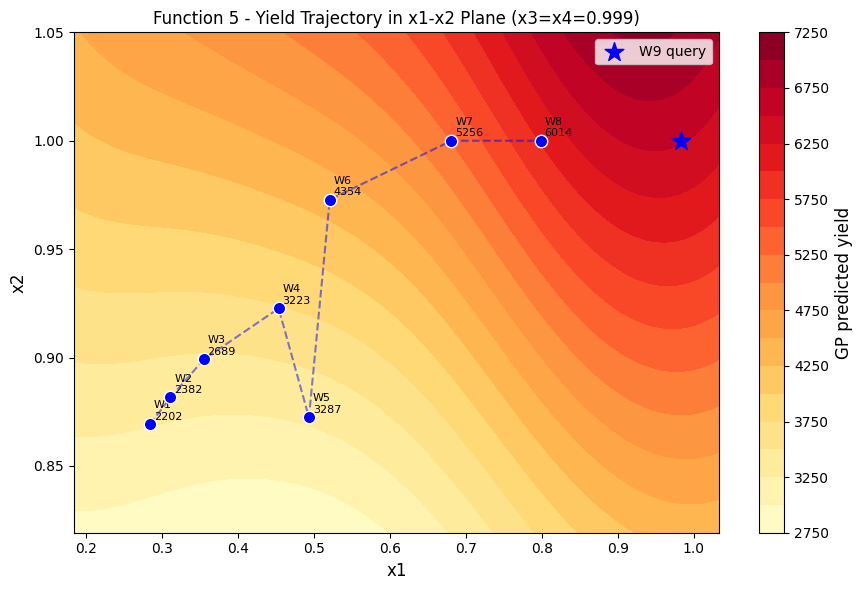

In [19]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
#   eighth consecutive improvement, so kept the overall pipiline.
# changes: 
#   - rised top indices threshold from 3000 to 5000
#   - EI xi raised to 0.01 from 0.005 (xi does not effect anything at all)
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 5 - Week 9")
print("=" * 60)
 
f5_inputs  = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')
 
prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1: 2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2: 2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3: 2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4: 3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5: 3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6: 4354.08
    [0.681041, 0.999999, 0.999999, 0.999999],  # W7: 5255.70
    [0.798393, 0.999999, 0.999999, 0.999999],  # W8: 6014.32
])
prev_outputs = np.array([
    2201.834589108927, 
    2381.536867607932, 
    2689.1537294933396,
    3223.2410694936825, 
    3286.9929500236235, 
    4354.076520735467,
    5255.707269541747,
    6014.320020319561,
])
 
all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")
 
# SVR -- changed epslion
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()
 
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)
 
# GP on log-transformed outputs -- same as W6
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)
 
best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)
 
# local candidates -- same as W6 with x3+x4 pinned
local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)
 
# directed candidates -- x1 up, x2 symmetric, x3+x4 pinned
directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)  # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)
 
candidates = np.vstack([local, directed])
 
# SVR pre-filter: top 3000
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()
 
top_idx  = np.argsort(svr_preds)[-5000:]
filtered = candidates[top_idx]
 
# GP + EI on log scale
mu_log, sigma_log = gp.predict(filtered, return_std=True)
ei                = compute_ei(mu_log, sigma_log, np.log1p(all_outputs.max()), xi=0.01)
 
best_idx = np.argmax(ei)
query    = filtered[best_idx]
 
print(f"\nWeek 9 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx]]:.2f}")
print(f"EI:                 {ei[best_idx]:.6f}")
 
# --- Interpretability ---
# --- GP vs SVR comparison at all query points 
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
 
# --- stats and plots 
# check what GP and SVR predict at different values
print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


# check x2
print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
    
# --- Plot 1: GP profile along x1 with uncertainty and EI ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

x1_sweep = np.linspace(0.2, 1.0, 500)
sweep_4d = np.column_stack([x1_sweep,
                            np.full(500, 0.999999),
                            np.full(500, 0.999999),
                            np.full(500, 0.999999)])

mu_sweep, sigma_sweep = gp.predict(sweep_4d, return_std=True)
yield_mean = np.expm1(mu_sweep)
yield_upper = np.expm1(mu_sweep + 1.96 * sigma_sweep)
yield_lower = np.expm1(mu_sweep - 1.96 * sigma_sweep)

# top panel: GP mean + uncertainty
ax1.plot(x1_sweep, yield_mean, 'k-', linewidth=2, label='GP mean')
ax1.fill_between(x1_sweep, yield_lower, yield_upper, alpha=0.2, color='steelblue',
                 label='95% CI')

# overlay query history
for i in range(len(prev_queries)):
    ax1.scatter(prev_queries[i, 0], prev_outputs[i], c='blue',
                edgecolors='white', s=80, zorder=5)
    ax1.annotate(f'W{i+1}', (prev_queries[i, 0] + 0.008, prev_outputs[i]),
                 fontsize=8)

ax1.axvline(query[0], color='red', linestyle='--', alpha=0.7, label=f'W8 query ({query[0]:.3f})')
ax1.set_ylim(0, 8000)
ax1.set_ylabel('Yield')
ax1.set_title('Function 5 - GP Profile Along x1 (x2=x3=x4=0.999)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# bottom panel: EI
ei_sweep = compute_ei(mu_sweep, sigma_sweep, np.log1p(all_outputs.max()), xi=0.01)
ax2.fill_between(x1_sweep, 0, ei_sweep, alpha=0.4, color='coral')
ax2.axvline(query[0], color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('EI')
ax2.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

# --- Plot 2: Fixed contour with correct x1 range ---
# --- Plot 2: Contour with auto-scaled bounds ---
pad = 0.05
x1_min = min(prev_queries[:, 0].min(), query[0]) - 0.1
x1_max = max(prev_queries[:, 0].max(), query[0]) + pad
x2_min = min(prev_queries[:, 1].min(), query[1]) - pad
x2_max = max(prev_queries[:, 1].max(), query[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries)):
    ax.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                (prev_queries[i, 0] + 0.005, prev_queries[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W9 query')

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
ax.legend()
fig.tight_layout()
plt.show()

# Function 6 - week 9


Function 6 - Week 9
Total observations: 28, best so far: -0.2947

SVR Hyperparameter LOO Grid
config                           MAE      R²   MSE@top3
------------------------------------------------------
g=0.05 C=1 e=0.01             0.1896  0.8243    +0.3046 *
g=0.05 C=1 e=0.05             0.2010  0.8084    +0.3116
g=0.05 C=1 e=0.1              0.2082  0.7984    +0.3416
g=0.05 C=10 e=0.01            0.1860  0.8456    +0.0847 *
g=0.05 C=10 e=0.05            0.1615  0.8750    +0.0695 *
g=0.05 C=10 e=0.1             0.1622  0.8706    +0.0990
g=0.05 C=50 e=0.01            0.2866  0.6805    +0.0190
g=0.05 C=50 e=0.05            0.1885  0.8370    +0.0395
g=0.05 C=50 e=0.1             0.1611  0.8714    +0.0939
g=0.1 C=1 e=0.01              0.1588  0.8736    +0.1154
g=0.1 C=1 e=0.05              0.1636  0.8619    +0.1082
g=0.1 C=1 e=0.1               0.1695  0.8526    +0.1234
g=0.1 C=10 e=0.01             0.2195  0.7939    +0.0056
g=0.1 C=10 e=0.05             0.1805  0.8334    +0.0406
g=0.

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_89458/705855098.py:113: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


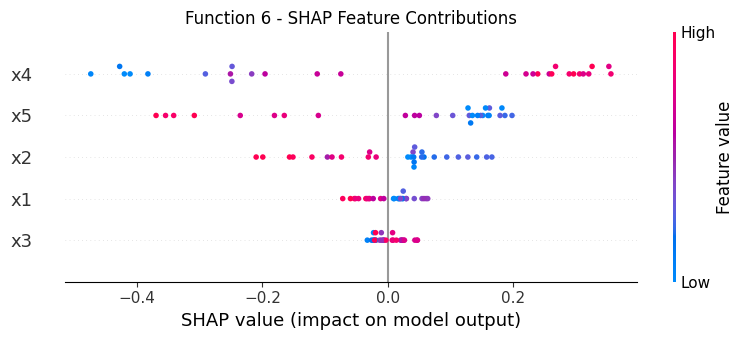

In [20]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# changes: 
#   - took out multi-surrogate test
#   - tested different combinations of SVR hyperparameters 
#   - changed gamma to 0.05 and epsilon to 0.05
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 6 - Week 9")
print("=" * 60)
 
f6_inputs  = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')
 
prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1: -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2: -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3: -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4: -0.315 
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5: -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6: -0.563
    [0.896209, 0.283983, 0.594508, 0.806739, 0.008612],  # W7: -0.764
    [0.482908, 0.318128, 0.672147, 0.855190, 0.203478],  # W8: -0.294 (best)
])
prev_outputs = np.array([
    -0.792246, 
    -0.361637, 
    -0.367626, 
    -0.314817, 
    -0.828981, 
    -0.5633934601648388, 
    -0.764298611557724,
    -0.29468304435774073,
])
 
all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])
 
print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")

# --- SVR hyperparameter LOO grid ---
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
best_pts = np.argsort(all_outputs)[-3:]

gammas = [0.05, 0.1, 0.2, 0.5, 1.0]
Cs = [1, 10, 50]
epsilons = [0.01, 0.05, 0.1]

print("\nSVR Hyperparameter LOO Grid")
print(f"{'config':<28} {'MAE':>7} {'R2':>7} {'MSE@top3':>10}")
print("-" * 54)

best_r2 = -999
best_config = ""

for g in gammas:
    for c in Cs:
        for e in epsilons:
            loo_preds = np.zeros(len(all_outputs))
            for train_idx, test_idx in loo.split(all_inputs):
                svr_loo = Pipeline([
                    ('scl', StandardScaler()),
                    ('svr', SVR(kernel='rbf', C=c, gamma=g, epsilon=e))
                ])
                svr_loo.fit(all_inputs[train_idx], all_outputs[train_idx])
                loo_preds[test_idx] = svr_loo.predict(all_inputs[test_idx].reshape(1, -1))[0]

            errors = all_outputs - loo_preds
            mae = np.mean(np.abs(errors))
            r2 = 1 - np.sum(errors**2) / np.sum((all_outputs - all_outputs.mean())**2)
            mse_top3 = errors[best_pts].mean()

            label = f"g={g} C={c} e={e}"
            marker = ""
            if r2 > best_r2:
                best_r2 = r2
                best_config = label
                marker = " *"
            print(f"{label:<28} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}{marker}")

print(f"\nBest by R2: {best_config} (R2={best_r2:.4f})")
 
# --- SVR new surrogate based on multi-surrgoate LOO comparision ---
svr = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma=0.05, epsilon=0.05))])
svr.fit(all_inputs, all_outputs)

space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)
candidates = np.array(lhs.generate(space.dimensions, 5000))

svr_preds = svr.predict(candidates)
best_index = np.argmax(svr_preds)
query = candidates[best_index]

print(f"\nWeek 9 Query (SVR): {format_query(query)}")
print(f"  Predicted value: {svr_preds[best_index]:.4f}")
 
# --- Interpretability: SHAP summary plot ---
# --- RF for SHAP
rf = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(all_inputs)
 
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

# Function 7 - week 9


Function 7 - Week 9
Total points: 38, best: 2.6016

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.648
  HP2: 0.129
  HP3: 0.041
  HP4: 0.026
  HP5: 0.059
  HP6: 0.097

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.08 subset)
Points with HP1 < 0.08: 11
Output range in subset: 0.009 to 2.602

Filtered RF importance:
  HP1: 0.067  (was 0.648 in full dataset) ***
  HP2: 0.437  (was 0.129 in full dataset) ***
  HP3: 0.059  (was 0.041 in full dataset) 
  HP4: 0.127  (was 0.026 in full dataset) ***
  HP5: 0.146  (was 0.059 in full dataset) 
  HP6: 0.164  (was 0.097 in full dataset) 

Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.648        1.105      0.211
  HP2           0.129        0.122      0.032
  HP3           0.041        0.024      0.005
  HP4           0.026        0.015      0.004
  HP5           0.059        0.049      0.010
  HP6           0.097        0.066      0.017

Permutation

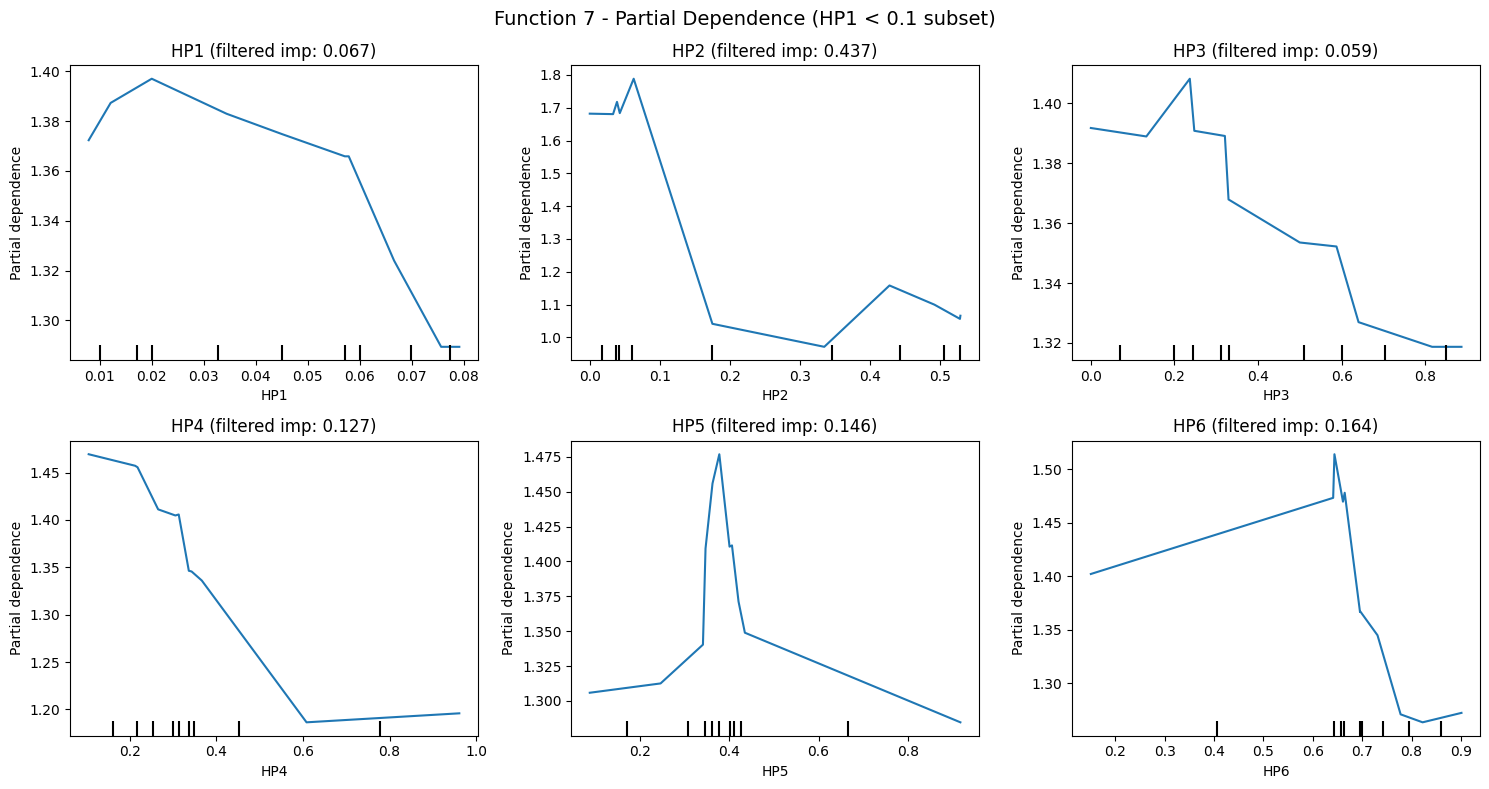

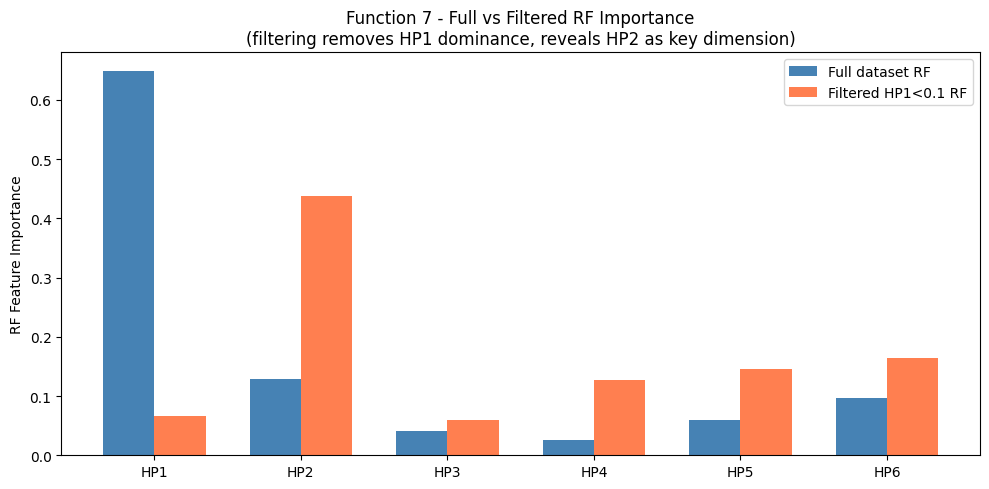

In [11]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes: 
#   - changed filter threshold from 0.1 to 0.08 based on diagnostic 
#      0.08 gives more consistent impurity vs permutation importance estimates
# =============================================================================

print("\n" + "=" * 60)
print("Function 7 - Week 9")
print("=" * 60)

f7_inputs  = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')

prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1: 1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2: 1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3: 2.602 (best)
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4: 1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5: 0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6: 1.790
    [0.079160, 0.042812, 0.886277, 0.366485, 0.400229, 0.661016],  # W7: 1.429
    [0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734],  # W8: 2.556
])
prev_outputs = np.array([
    1.0510006614196026, 
    1.6531363312716738, 
    2.6016443512251484,
    1.5087286481808686, 
    0.3832671270292543, 
    1.789927976010441,
    1.428502150382287,
    2.5567422716339334,
])

all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")

feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# --- Step 1b: Filtered RF (HP1 < threshold subset)
# threshold tightened from 0.1 to 0.08 based on diagnostic 
hp1_threshold = 0.08
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs[:, 0] < hp1_threshold
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")

# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs, all_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")

# --- Step 2: Sequential RF filtering 
print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates = np.random.uniform(0, 1, size=(n_initial, 6))

# Stage 1: full RF filters to top 10,000
full_preds = rf_full.predict(candidates)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")

# Stage 2: filtered RF filters to top 1,000
filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")

# --- Step 3: GP with UCB on filtered candidates
print("\nStep 3: GP with UCB (on 1,000 RF-filtered candidates)")

kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.log1p(all_outputs))

kappa = 1.5
mu, sigma = gp.predict(stage2, return_std=True)
ucb = mu + kappa * sigma

best_idx = np.argmax(ucb)
best_candidate = stage2[best_idx]

predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])

print(f"\nWeek 9 Query: {format_query(best_candidate)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")
print(f"UCB score (log scale)           : {ucb[best_idx]:.4f}")

# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# print("=" * 60)
# print("DIAGNOSTIC: HP1 filter threshold comparison")
# print("=" * 60)

# for threshold in [0.05, 0.08, 0.1, 0.15]:
#     mask = all_inputs[:, 0] < threshold
#     filt_in = all_inputs[mask]
#     filt_out = all_outputs[mask]
    
#     rf = RandomForestRegressor(n_estimators=200, random_state=42)
#     rf.fit(filt_in, filt_out)
    
#     perm = permutation_importance(rf, filt_in, filt_out, n_repeats=30, random_state=42)
    
#     print(f"\nHP1 < {threshold}: {mask.sum()} points, output range [{filt_out.min():.3f}, {filt_out.max():.3f}]")
#     print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12}")
#     for i, name in enumerate(feature_names):
#         print(f"  {name:<8} {rf.feature_importances_[i]:>10.3f} {perm.importances_mean[i]:>12.3f}")
    
#     # how well does this RF rank the known good points?
#     # predict W3 and W8 (the two best results)
#     w3_pred = rf.predict(prev_queries[2].reshape(1, -1))[0]
#     w8_pred = rf.predict(prev_queries[7].reshape(1, -1))[0]
#     print(f"  Prediction for W3 (actual 2.602): {w3_pred:.3f}")
#     print(f"  Prediction for W8 (actual 2.557): {w8_pred:.3f}")

# print("=" * 60)
# print("DIAGNOSTIC: RF min_samples_leaf comparison (HP1 < 0.08)")
# print("=" * 60)

# mask = all_inputs[:, 0] < 0.08
# filt_in = all_inputs[mask]
# filt_out = all_outputs[mask]

# for msl in [1, 2, 3]:
#     rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=msl, random_state=42)
#     rf.fit(filt_in, filt_out)
    
#     w3_pred = rf.predict(prev_queries[2].reshape(1, -1))[0]
#     w8_pred = rf.predict(prev_queries[7].reshape(1, -1))[0]
    
#     print(f"\nmin_samples_leaf={msl}:")
#     print(f"  Importance: " + "  ".join(f"HP{i+1}={rf.feature_importances_[i]:.3f}" for i in range(6)))
#     print(f"  W3 pred: {w3_pred:.3f}  W8 pred: {w8_pred:.3f}")

# Function 8 - week 9


Function 8 - Week 9
Total points: 48, best: 9.6741 (W1)

LOO Calibration (dropout=0.25):
  mean |error|:        0.2687
  std  |error|:        0.2375
  max  |error|:        1.0397
  mean sigma (LOO):    0.2621
  ratio (error/sigma): 1.025  (1.0 = perfect calibration)
  kappa (adaptive):    1.74
Training loss (final): 0.0797


  0%|          | 0/48 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_89458/687430972.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


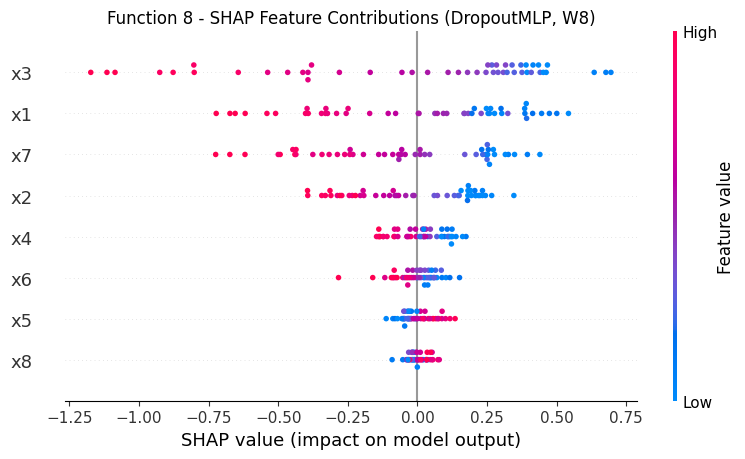


SHAP-derived importance (normalised):
  x1: 0.713
  x2: 0.441
  x3: 1.000
  x4: 0.178
  x5: 0.104
  x6: 0.129
  x7: 0.604
  x8: 0.062

Refinement anchor (W1): [1.34058e-01 1.05170e-02 0.00000e+00 7.05000e-04 9.91616e-01 1.10483e-01
 8.47020e-02 1.28780e-02] -> 9.6741
Candidate pool: 35000 refinement + 15000 x3-sweep = 50000 total

mu   range: 7.758 to 9.717
sigma range: 0.180 to 0.477
kappa*sigma range: 0.314 to 0.832

Week 9 Query: 0.168188-0.021624-0.000000-0.000668-0.988557-0.107416-0.053647-0.014730
Source: Pool A (refinement)
MC mu: 9.6371, sigma: 0.3710
UCB:   10.2837


In [21]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   - halved the perturbation (noise) values of pool a's candidates
#   - MLP raised n_passes from 50 to 100
# =============================================================================

print("\n" + "=" * 60)
print("Function 8 - Week 9")
print("=" * 60)

f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')

prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1: 9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2: 9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3: 9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4: 9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5: 9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6: 9.620
    [0.000000, 0.000000, 0.000000, 0.120009, 0.144817, 0.385066, 0.000000, 0.986589],  # W7: 9.583
    [0.134058, 0.010517, 0.000000, 0.000705, 0.991616, 0.110483, 0.084702, 0.012878],  # W8: 9.674 (best)
])
prev_outputs = np.array([
    9.6723503773075, 
    9.6263579169495, 
    9.5463675507445,
    9.5519471979855, 
    9.1457303782294, 
    9.6199985919071,
    9.5831132283264,
    9.6740952800446,
])

all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f} (W1)")

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

# Adaptive kappa: base * calibration ratio
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa:.2f}")

# train final model
torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")

# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP, W8)')
plt.tight_layout()
plt.show()

model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# --- Candidate pool: Pool A (refinement) + Pool B (x3 sweep) ---
# W1 is the actual best point — anchor refinement there
w1_point = all_inputs[np.argmax(all_outputs)]
print(f"\nRefinement anchor (W1): {w1_point} -> {all_outputs.max():.4f}")

np.random.seed(42)

# Pool A: 35k points, tight perturbation around W1
# Active dims (x1, x3, x7): noise scale 0.05-0.08 based on SHAP
# Settled dims (x2, x4, x5, x6, x8): noise scale 0.01-0.02
pool_a_noise = np.random.randn(35000, 8)
for dim in range(8):
    if shap_importance[dim] > 0.5:
        pool_a_noise[:, dim] *= 0.025 + 0.015 * shap_importance[dim]
    else:
        pool_a_noise[:, dim] *= 0.005 + 0.005 * shap_importance[dim]

pool_a = np.clip(w1_point + pool_a_noise, 0, 1)

# Pool B: 15k points, structured x3 sweep
# Fix x2=0, x4=0, x5=1, x8=0, x6~0.127 at W1 values
# Sweep x3 from 0 to 1, sample x1 and x7 with moderate noise around W1
pool_b = np.zeros((15000, 8))
pool_b[:, 2] = np.random.uniform(0, 1, 15000)          # x3: full sweep
pool_b[:, 0] = np.clip(w1_point[0] + np.random.randn(15000) * 0.15, 0, 1)  # x1: moderate noise
pool_b[:, 6] = np.clip(w1_point[6] + np.random.randn(15000) * 0.15, 0, 1)  # x7: moderate noise
pool_b[:, 1] = 0.0   # x2
pool_b[:, 3] = 0.0   # x4
pool_b[:, 4] = 1.0   # x5
pool_b[:, 5] = np.clip(w1_point[5] + np.random.randn(15000) * 0.02, 0, 1)  # x6: tight jitter
pool_b[:, 7] = 0.0   # x8

pool = np.vstack([pool_a, pool_b])
print(f"Candidate pool: {len(pool_a)} refinement + {len(pool_b)} x3-sweep = {len(pool)} total")

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb      = mu + kappa * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]

# report which pool the query came from
pool_source = "Pool A (refinement)" if best_idx < len(pool_a) else "Pool B (x3-sweep)"

print(f"\nmu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma).min():.3f} to {(kappa*sigma).max():.3f}")

print(f"\nWeek 9 Query: {format_query(query)}")
print(f"Source: {pool_source}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")